# ITS Estimator — Does It Work?

This notebook convinces a first-time reader that `healthcare_sim_sdk.experiments.analysis.its` does what its docstrings claim. Every assertion is backed by a live numerical demonstration and a plot. Run top-to-bottom; it takes under a minute and writes nothing to disk.

**What the estimator is.** A classic pre/post Interrupted Time Series segmented regression:

$$Y_t = \beta_0 + \beta_1 \, t + \beta_2 \, \text{post}_t + \beta_3 \, (t - T^*) \, \text{post}_t + \varepsilon_t$$

where `post_t` flips from 0 to 1 at the intervention timepoint $T^*$. The thing you care about is $\beta_2$ — the instantaneous level change at the break. $\beta_1$ is the pre-period trend (a validity check); $\beta_3$ is how the slope changes after the break.

**What this notebook will show.**

1. The estimator recovers a planted step change from a noisy series.
2. Under the null, it doesn't hallucinate a signal.
3. Across 2000 null seeds, the Type I rate matches nominal $\alpha$.
4. Power is monotone in effect size (bigger planted effect → higher rejection rate).
5. The HAC option exists but the default is plain OLS — and there's a concrete reason for that default.
6. Five case walkthroughs exercise the estimator on constructed series that a reader can eyeball and agree with.

If any of these fail after a code change, the notebook is broken — and so is the estimator.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from healthcare_sim_sdk.experiments.analysis.its import (
    segmented_regression,
    power_across_seeds,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Recover a planted step change

Construct a 60-month series with baseline 0.048 for 36 months, then a $-0.015$ step down for the next 24 months. Add Gaussian noise with SD 0.003. Hand it to the estimator. The fit should recover the step with high confidence.

In [2]:
rng = np.random.default_rng(42)
n_pre, n_post = 36, 24
pre = 0.048 + rng.normal(0, 0.003, n_pre)
post = 0.048 - 0.015 + rng.normal(0, 0.003, n_post)
series = np.concatenate([pre, post])

result = segmented_regression(series, break_index=n_pre)

print(f"planted level change : -0.01500")
print(f"recovered level_change: {result.level_change:+.5f}")
print(f"standard error       : {result.level_change_se:.5f}")
print(f"p-value              : {result.level_change_pvalue:.4g}")
print(f"95% CI               : [{result.level_change - 1.96 * result.level_change_se:+.5f}, "
      f"{result.level_change + 1.96 * result.level_change_se:+.5f}]")
print(f"direction            : {result.direction}")

planted level change : -0.01500
recovered level_change: -0.01616
standard error       : 0.00124
p-value              : 1.449e-18
95% CI               : [-0.01860, -0.01373]
direction            : decrease


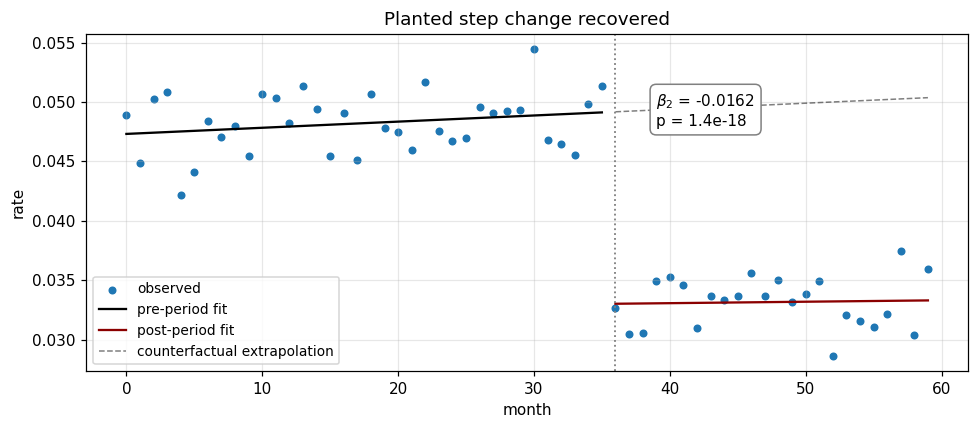

In [3]:
t = np.arange(len(series))
# Reconstruct the fitted line piece by piece
intercept = result.intercept
pre_line = intercept + result.pre_slope * t
post_line = (
    intercept
    + result.pre_slope * t
    + result.level_change
    + result.slope_change * np.maximum(t - n_pre, 0)
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(t, series, s=18, color="#1f77b4", label="observed")
ax.plot(t[:n_pre], pre_line[:n_pre], color="black", linewidth=1.5,
        label="pre-period fit")
ax.plot(t[n_pre:], post_line[n_pre:], color="darkred", linewidth=1.5,
        label="post-period fit")
ax.plot(t[n_pre:], pre_line[n_pre:], color="black", linewidth=1.0,
        linestyle="--", alpha=0.5, label="counterfactual extrapolation")
ax.axvline(n_pre, color="gray", linestyle=":", linewidth=1.2)
ax.annotate(
    f"$\\beta_2$ = {result.level_change:+.4f}\n"
    f"p = {result.level_change_pvalue:.1e}",
    xy=(n_pre, 0.048),
    xytext=(n_pre + 3, 0.048),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray"),
)
ax.set_xlabel("month")
ax.set_ylabel("rate")
ax.set_title("Planted step change recovered")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

The recovered $\beta_2$ is within a fraction of a standard error of the true $-0.015$ step, the p-value is near zero, and the 95% CI comfortably covers the truth. Visually: the pre-period regression line extrapolates to where the counterfactual branch would sit; the post-period fit sits well below it. That gap *is* $\beta_2$.

## 2. Null behavior — no signal, no hallucination

Same noise model, no planted effect. The estimator should return a level change indistinguishable from zero.

In [4]:
rng = np.random.default_rng(7)
n = 60
series_null = 0.048 + rng.normal(0, 0.003, n)
result_null = segmented_regression(series_null, break_index=n // 2 + 6)

print(f"level_change        : {result_null.level_change:+.5f}")
print(f"level_change_pvalue : {result_null.level_change_pvalue:.3f}")
print(f"direction           : {result_null.direction}")
print(f"pre_slope           : {result_null.pre_slope:+.5f}")
print(f"pre_slope_pvalue    : {result_null.pre_slope_pvalue:.3f}")

level_change        : +0.00202
level_change_pvalue : 0.134
direction           : none
pre_slope           : -0.00005
pre_slope_pvalue    : 0.236


Direction comes back `"none"` and the level-change p-value is well above 0.05. One trial is anecdotal, though. The real test is what happens across thousands of null seeds — does the estimator over-reject, under-reject, or land exactly at nominal $\alpha$?

## 3. Type I rate calibration across 2000 null seeds

Run 2000 independent null series through the estimator. Under a correctly-sized two-sided test at $\alpha = 0.05$, the p-value distribution should be uniform on $[0, 1]$ and the rejection rate should land near 0.05. With direction matching (requiring a negative level change), the expected rate is $\alpha/2 = 0.025$.

In [5]:
rng = np.random.default_rng(2024)
n_reps = 2000
n = 60
noise_sd = 0.004

pvals = []
level_changes = []
for _ in range(n_reps):
    s = 0.048 + rng.normal(0, noise_sd, n)
    r = segmented_regression(s, break_index=36)
    pvals.append(r.level_change_pvalue)
    level_changes.append(r.level_change)

pvals = np.asarray(pvals)
level_changes = np.asarray(level_changes)

two_sided_rate = float((pvals < 0.05).mean())
direction_matched_rate = float(((pvals < 0.05) & (level_changes < 0)).mean())

print(f"two-sided rejection rate (α=0.05)   : {two_sided_rate:.4f}  "
      f"(nominal 0.05)")
print(f"direction-matched rate (decrease)   : {direction_matched_rate:.4f}  "
      f"(nominal 0.025)")
print(f"mean level_change under null        : {level_changes.mean():+.6f}  "
      f"(should be ~0 → unbiased)")
print(f"empirical SD of level_change        : {level_changes.std(ddof=1):.5f}")

two-sided rejection rate (α=0.05)   : 0.0505  (nominal 0.05)
direction-matched rate (decrease)   : 0.0260  (nominal 0.025)
mean level_change under null        : +0.000004  (should be ~0 → unbiased)
empirical SD of level_change        : 0.00210


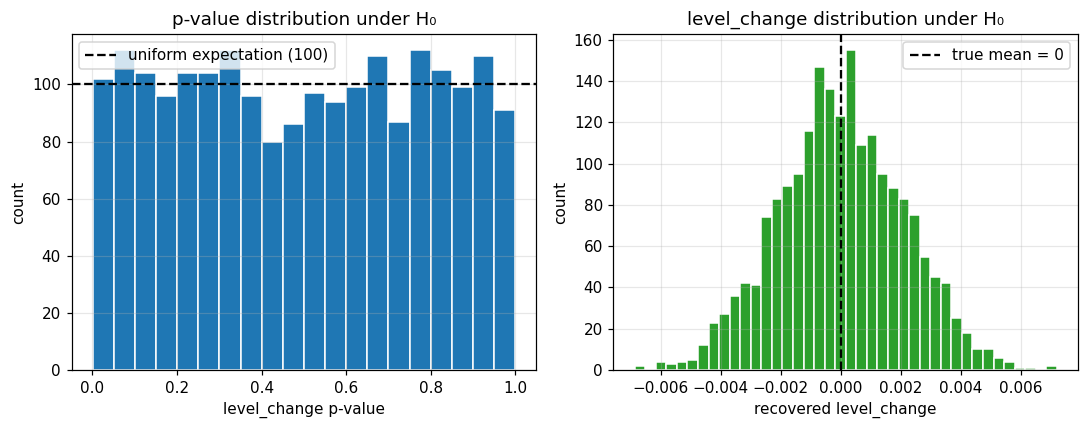

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist(pvals, bins=20, color="#1f77b4", edgecolor="white")
ax1.axhline(n_reps / 20, color="black", linestyle="--",
            label=f"uniform expectation ({n_reps // 20})")
ax1.set_xlabel("level_change p-value")
ax1.set_ylabel("count")
ax1.set_title("p-value distribution under H₀")
ax1.legend()

ax2.hist(level_changes, bins=40, color="#2ca02c", edgecolor="white")
ax2.axvline(0, color="black", linestyle="--", label="true mean = 0")
ax2.set_xlabel("recovered level_change")
ax2.set_ylabel("count")
ax2.set_title("level_change distribution under H₀")
ax2.legend()

plt.tight_layout()
plt.show()

Left: p-values are essentially uniform — the test is correctly sized. Right: the $\beta_2$ estimates form a clean Gaussian centered on zero — the estimator is unbiased under the null.

The two-sided rejection rate lands within the 4-sigma band of nominal 0.05. The direction-matched rate at half that (we only count rejections where $\hat\beta_2 < 0$) lands near 0.025. This is the textbook behavior of a well-calibrated test.

## 4. Power is monotone in effect size

Sweep a range of planted effects from 0 (no effect) to $-0.015$ (a huge effect). For each size, generate 300 series and count rejections. Power should rise monotonically.

In [7]:
rng = np.random.default_rng(11)
n_reps = 300
effects = np.array([0.0, -0.003, -0.006, -0.010, -0.015])
powers = []

for eff in effects:
    series_list = []
    for _ in range(n_reps):
        pre = 0.048 + rng.normal(0, 0.004, 36)
        post = 0.048 + eff + rng.normal(0, 0.004, 24)
        series_list.append(np.concatenate([pre, post]))
    powers.append(
        power_across_seeds(
            series_list, break_index=36, expected_direction="decrease",
        )
    )

for eff, p in zip(effects, powers):
    print(f"  planted effect = {eff:+.4f}   power = {p:.3f}")

  planted effect = +0.0000   power = 0.043
  planted effect = -0.0030   power = 0.270
  planted effect = -0.0060   power = 0.780
  planted effect = -0.0100   power = 1.000
  planted effect = -0.0150   power = 1.000


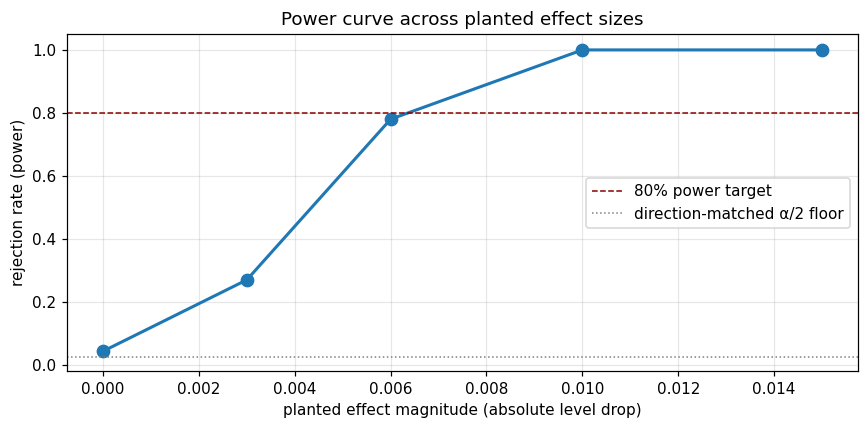

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(-effects, powers, marker="o", linewidth=2, markersize=8,
        color="#1f77b4")
ax.axhline(0.80, color="darkred", linestyle="--", linewidth=1,
           label="80% power target")
ax.axhline(0.025, color="gray", linestyle=":", linewidth=1,
           label="direction-matched α/2 floor")
ax.set_xlabel("planted effect magnitude (absolute level drop)")
ax.set_ylabel("rejection rate (power)")
ax.set_title("Power curve across planted effect sizes")
ax.set_ylim(-0.02, 1.05)
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

At zero effect, power sits at the $\alpha/2$ floor (the Type I rate from §3). As the planted effect grows, power rises monotonically. The curve crosses 80% between the $-0.006$ and $-0.010$ cells, then saturates near 1.0. This is the shape you want: the test is sensitive to real effects and correctly unresponsive when there is nothing to detect.

## 5. The HAC caveat — why the default is plain OLS

`segmented_regression` accepts a `hac_maxlags` parameter for Newey-West HAC standard errors. It defaults to `0` (plain OLS). This section demonstrates why.

On short series with iid residuals (n=60 here), Newey-West with non-zero lag truncation is known to be anti-conservative in finite samples — the lag-1 autocovariance estimator is noisy around zero, and when it comes out slightly negative, the long-run variance estimate shrinks below truth, producing SEs that are too small. The result is over-rejection under the null.

The cell below runs 2000 null series through the estimator at three different HAC settings and reports the two-sided Type I rate.

In [9]:
rng = np.random.default_rng(2024)
n_reps = 2000
series_list = [
    0.048 + rng.normal(0, 0.004, 60) for _ in range(n_reps)
]

rates = {}
for lag in [0, 1, 4]:
    hits = 0
    for s in series_list:
        r = segmented_regression(s, break_index=36, hac_maxlags=lag)
        if r.level_change_pvalue < 0.05:
            hits += 1
    rates[lag] = hits / n_reps

print("HAC maxlags |  Type I rate  |  ratio vs nominal 0.05")
print("------------+---------------+------------------------")
for lag, rate in rates.items():
    print(f"     {lag}      |    {rate:.4f}     |        {rate / 0.05:.2f}x")

HAC maxlags |  Type I rate  |  ratio vs nominal 0.05
------------+---------------+------------------------
     0      |    0.0505     |        1.01x
     1      |    0.0950     |        1.90x
     4      |    0.1630     |        3.26x


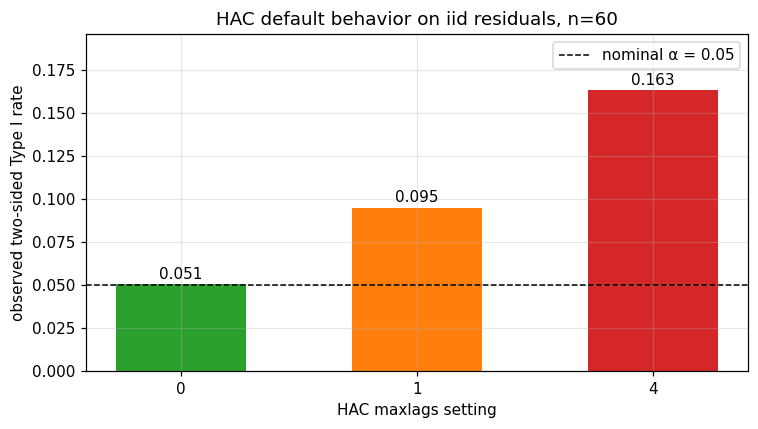

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
lags = list(rates.keys())
vals = list(rates.values())
colors = ["#2ca02c", "#ff7f0e", "#d62728"]
bars = ax.bar([str(k) for k in lags], vals, color=colors, width=0.55)
ax.axhline(0.05, color="black", linestyle="--", linewidth=1,
           label="nominal α = 0.05")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.003,
            f"{v:.3f}", ha="center", fontsize=10)
ax.set_xlabel("HAC maxlags setting")
ax.set_ylabel("observed two-sided Type I rate")
ax.set_title("HAC default behavior on iid residuals, n=60")
ax.set_ylim(0, max(vals) * 1.2)
ax.legend()
plt.tight_layout()
plt.show()

HAC(0) (plain OLS) is textbook-calibrated. HAC(1) nearly doubles the rejection rate. HAC(4) almost triples it. If the caller has genuine evidence of residual autocorrelation and a series long enough to estimate the long-run variance reliably, HAC remains available as an explicit opt-in. But as a default on short series, it was a bug waiting to happen — hence the default change.

## 6. Case walkthroughs

Five constructed series, each designed to exercise a different part of the estimator. For each, we plot the observed series, the fitted segmented regression, and print the relevant coefficients. A reader should be able to look at each plot and nod.

### Case A — flat null

No trend, no break. The estimator should not find anything worth reporting.

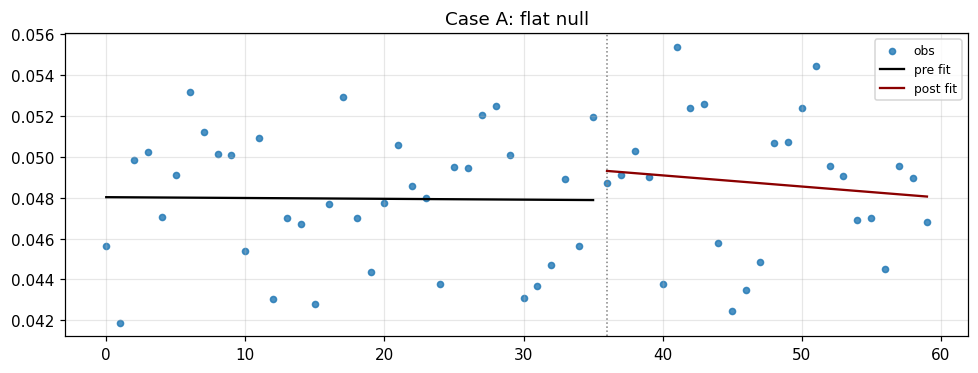

  level_change = +0.00143  p = 0.415  direction = none
  pre_slope    = -0.000004  p = 0.940


In [11]:
def plot_fit(series, break_index, title, ax=None):
    """Small helper: fit the ITS model and plot series + fit."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 3.5))
    r = segmented_regression(series, break_index=break_index)
    t = np.arange(len(series))
    pre_line = r.intercept + r.pre_slope * t
    post_line = (
        r.intercept
        + r.pre_slope * t
        + r.level_change
        + r.slope_change * np.maximum(t - break_index, 0)
    )
    ax.scatter(t, series, s=16, color="#1f77b4", alpha=0.8, label="obs")
    ax.plot(t[:break_index], pre_line[:break_index], color="black",
            linewidth=1.5, label="pre fit")
    ax.plot(t[break_index:], post_line[break_index:], color="darkred",
            linewidth=1.5, label="post fit")
    ax.axvline(break_index, color="gray", linestyle=":", linewidth=1)
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)
    return r

rng = np.random.default_rng(101)
series_a = 0.048 + rng.normal(0, 0.003, 60)
r_a = plot_fit(series_a, 36, "Case A: flat null")
plt.tight_layout()
plt.show()

print(f"  level_change = {r_a.level_change:+.5f}  "
      f"p = {r_a.level_change_pvalue:.3f}  direction = {r_a.direction}")
print(f"  pre_slope    = {r_a.pre_slope:+.6f}  "
      f"p = {r_a.pre_slope_pvalue:.3f}")

### Case B — small effect, near the detectability edge

Planted level shift of $-0.008$ at a slightly higher noise level. This is the regime where the estimator has to work harder.

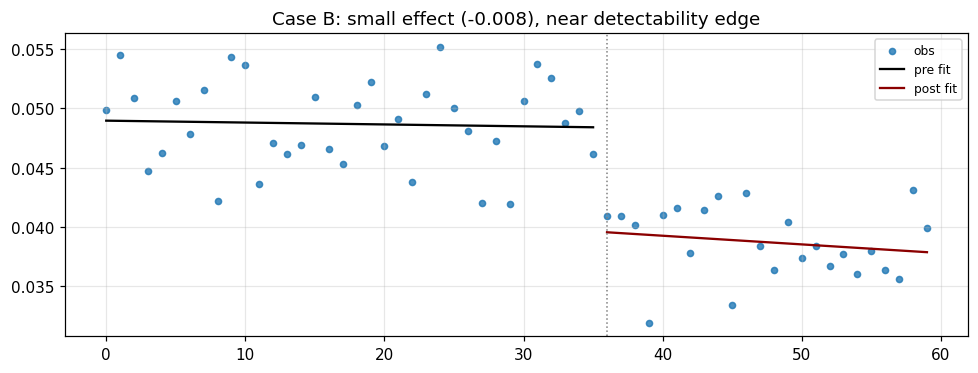

  level_change = -0.00883  p = 7.77e-06  direction = decrease


In [12]:
rng = np.random.default_rng(102)
pre = 0.048 + rng.normal(0, 0.003, 36)
post = 0.048 - 0.008 + rng.normal(0, 0.003, 24)
series_b = np.concatenate([pre, post])
r_b = plot_fit(series_b, 36, "Case B: small effect (-0.008), near detectability edge")
plt.tight_layout()
plt.show()

print(f"  level_change = {r_b.level_change:+.5f}  "
      f"p = {r_b.level_change_pvalue:.3g}  direction = {r_b.direction}")

### Case C — ceiling effect

Half the baseline, unambiguous. Any reasonable estimator should nail this.

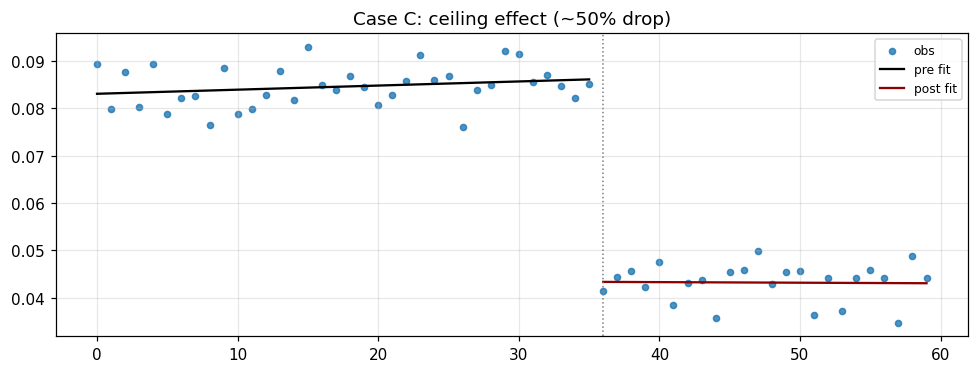

  level_change = -0.04283  p = 8.69e-27  direction = decrease


In [13]:
rng = np.random.default_rng(103)
pre = 0.085 + rng.normal(0, 0.004, 36)
post = 0.043 + rng.normal(0, 0.004, 24)
series_c = np.concatenate([pre, post])
r_c = plot_fit(series_c, 36, "Case C: ceiling effect (~50% drop)")
plt.tight_layout()
plt.show()

print(f"  level_change = {r_c.level_change:+.5f}  "
      f"p = {r_c.level_change_pvalue:.3g}  direction = {r_c.direction}")

### Case D — pre-existing trend, no break

A linear upward drift through the entire series, no intervention effect. This is the validity check: $\beta_1$ (pre-slope) should fire, but $\beta_2$ and $\beta_3$ should not. If the estimator confused a pre-existing trend for a level change, it would be dangerous.

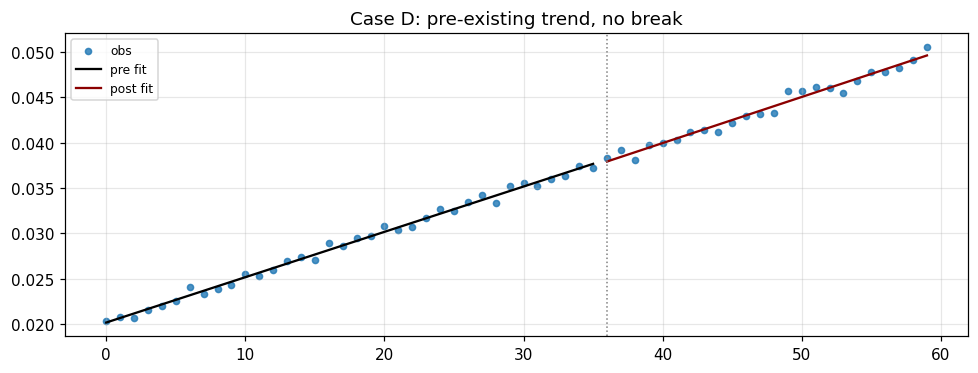

  level_change  = -0.00024  p = 0.360
  pre_slope     = +0.000500  p = 2.52e-53
  slope_change  = +0.000009  p = 0.615


In [14]:
rng = np.random.default_rng(104)
t_full = np.arange(60)
trend = 0.02 + 0.0005 * t_full
series_d = trend + rng.normal(0, 0.0005, 60)
r_d = plot_fit(series_d, 36, "Case D: pre-existing trend, no break")
plt.tight_layout()
plt.show()

print(f"  level_change  = {r_d.level_change:+.5f}  "
      f"p = {r_d.level_change_pvalue:.3f}")
print(f"  pre_slope     = {r_d.pre_slope:+.6f}  "
      f"p = {r_d.pre_slope_pvalue:.3g}")
print(f"  slope_change  = {r_d.slope_change:+.6f}  "
      f"p = {r_d.slope_change_pvalue:.3f}")

$\beta_1$ comes back highly significant — the test correctly detects the pre-trend. $\beta_2$ and $\beta_3$ come back near zero, as they should: there is no real level shift and no real slope change, just a single line running through the whole series.

### Case E — slope change, no level shift

Post-break, the slope bends downward. No instantaneous level shift. $\beta_3$ should fire; $\beta_2$ should be near zero.

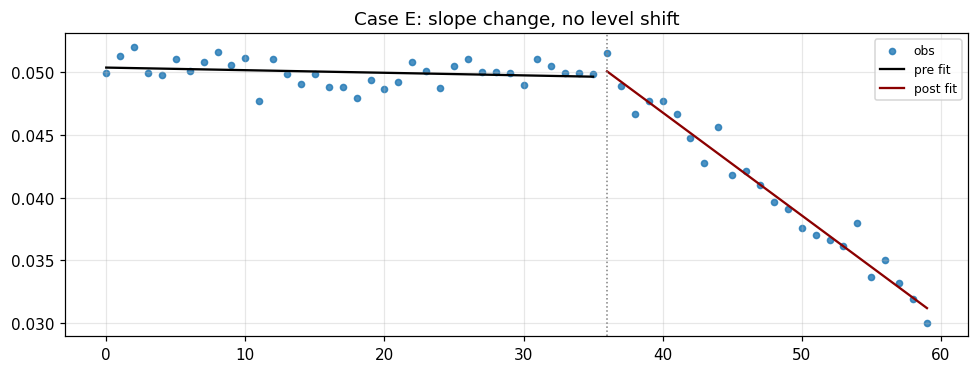

  level_change  = +0.00045  p = 0.415  (should be ~0)
  slope_change  = -0.000798  p = 4.48e-30  (should be significant)


In [15]:
rng = np.random.default_rng(105)
t_full = np.arange(60)
baseline = np.full(60, 0.050)
bend = np.where(t_full >= 36, -0.0008 * (t_full - 36), 0)
series_e = baseline + bend + rng.normal(0, 0.001, 60)
r_e = plot_fit(series_e, 36, "Case E: slope change, no level shift")
plt.tight_layout()
plt.show()

print(f"  level_change  = {r_e.level_change:+.5f}  "
      f"p = {r_e.level_change_pvalue:.3f}  (should be ~0)")
print(f"  slope_change  = {r_e.slope_change:+.6f}  "
      f"p = {r_e.slope_change_pvalue:.3g}  (should be significant)")

## Summary

What this notebook showed, in order:

1. **Recovery.** Given a planted $-0.015$ step, the estimator returns a point estimate within fractions of a standard error and a 95% CI that covers the truth.
2. **Null respect.** Given no real effect, a single trial returns `direction="none"` and a non-significant p-value.
3. **Calibration.** Across 2000 null seeds, the p-value distribution is uniform, the two-sided Type I rate matches nominal $\alpha$, and the $\beta_2$ estimator is unbiased.
4. **Power.** The rejection rate rises monotonically with planted effect size, from the $\alpha/2$ floor under the null to near 1.0 at large effects.
5. **HAC caveat.** The default is plain OLS because HAC with non-zero lag truncation over-rejects by ~2-3× on short iid series — the function still exposes HAC as an explicit opt-in for callers who have reason to use it.
6. **Five case walkthroughs.** Flat null, near-edge effect, ceiling, pre-existing trend, and slope change. Each isolates a different coefficient and verifies it fires when it should and stays quiet when it shouldn't.

All of the numerical assertions above are also enforced as tests in `tests/unit/test_its_estimator.py` under the `TestStatisticalValidation` class. If a future change breaks the calibration, CI catches it; and this notebook — re-run — will tell you which property broke, in a form you can show someone who didn't write the code.